# 2.3 Random Forest Oslo

## Table of Contents
### 1. Import Libraries and Data

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn import datasets  
from sklearn.ensemble import RandomForestClassifier
from numpy import argmax
from sklearn.model_selection import train_test_split
from sklearn import metrics  
from sklearn.tree import plot_tree
from sklearn import tree
import warnings

In [6]:
# Import unscaled weather data
path = r'/Users/daxma/OneDrive/Desktop/Data Analytics/Machine Learning with Python/07-25 ClimateWins Analysis/02 Data'

df = pd.read_csv(os.path.join(path,'Prepared Data', 'weather_unscaled_clean.csv'))

In [7]:
# Check output
df.head()

,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,BASEL_temp_max,BELGRADE_cloud_cover,...,STOCKHOLM_temp_max,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
0,7,0.85,1.018,0.32,0.09,0.7,6.5,0.8,10.9,1,...,4.9,5,0.88,1.0003,0.45,0.34,4.7,8.5,6.0,10.9
1,6,0.84,1.018,0.36,1.05,1.1,6.1,3.3,10.1,6,...,5.0,7,0.91,1.0007,0.25,0.84,0.7,8.9,5.6,12.1
2,8,0.90,1.018,0.18,0.30,0.0,8.5,5.1,9.9,6,...,4.1,7,0.91,1.0096,0.17,0.08,0.1,10.5,8.1,12.9
3,3,0.92,1.018,0.58,0.00,4.1,6.3,3.8,10.6,8,...,2.3,7,0.86,1.0184,0.13,0.98,0.0,7.4,7.3,10.6
4,6,0.95,1.018,0.65,0.14,5.4,3.0,-0.7,6.0,8,...,4.3,3,0.80,1.0328,0.46,0.00,5.7,5.7,3.0,8.4


In [8]:
# Import pleasant weather answers
pleasant = pd.read_csv(os.path.join(path, 'Original Data', 'Pleasant_Weather_Answers.csv'))

In [9]:
# Check output
pleasant.head()

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
0,19600101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,19600102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,19600103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,19600104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,19600105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 2. Data Wrangling

In [11]:
# Reduce data to only Oslo columns
oslo_list = list(x for x in df.columns if x.find('OSLO') >=0)
oslo_list

df_oslo = df[oslo_list]
df_oslo

,OSLO_cloud_cover,OSLO_humidity,OSLO_pressure,OSLO_global_radiation,OSLO_precipitation,OSLO_sunshine,OSLO_temp_mean,OSLO_temp_min,OSLO_temp_max
0,8,0.98,0.9978,0.04,1.14,0.0,4.9,3.8,5.9
1,8,0.62,1.0139,0.04,0.00,0.0,3.4,2.8,4.9
2,8,0.69,1.0234,0.04,0.08,0.0,1.9,0.6,3.1
3,8,0.98,1.0244,0.04,0.35,0.0,3.0,0.4,4.9
4,8,0.96,1.0092,0.05,0.26,0.0,3.7,2.9,4.9
...,...,...,...,...,...,...,...,...,...
22945,8,0.98,1.0139,1.06,0.21,0.1,9.7,5.8,12.0
22946,8,1.00,1.0107,1.06,0.21,0.0,10.9,8.8,11.7
22947,3,0.85,1.0082,1.06,0.21,6.8,9.7,7.7,14.2
22948,5,0.94,1.0150,1.06,0.21,2.9,5.9,2.1,8.1


In [12]:
# Reduce plesant answers dataset to Basel only

answers_oslo = pleasant['OSLO_pleasant_weather']
answers_oslo

0        0
1        0
2        0
3        0
4        0
        ..
22945    0
22946    0
22947    0
22948    0
22949    0
Name: OSLO_pleasant_weather, Length: 22950, dtype: int64

## 3. Reshape for Modeling

In [14]:
X2 = df_oslo

In [15]:
y2 = answers_oslo

In [16]:
# Turn df's to arrays

X = np.array(X2)
y = np.array(y2)

In [17]:
X.shape

(22950, 9)

In [18]:
y.shape

(22950,)

## 4. Splitting Data

In [20]:
# Split data into train and test sets

X_train, X_test, y_train, y_test = train_test_split(X,y,random_state = 42)

In [21]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(17212, 9) (17212,)
(5738, 9) (5738,)


In [22]:
X_train

array([[  2.    ,   0.48  ,   1.0207, ...,  10.5   ,   6.2   ,  16.5   ],
       [  4.    ,   0.88  ,   1.0101, ..., -11.2   , -13.8   ,  -8.2   ],
       [  4.    ,   0.77  ,   1.0202, ..., -14.4   , -19.    , -11.7   ],
       ...,
       [  8.    ,   0.72  ,   1.0083, ...,   6.4   ,   5.2   ,   9.5   ],
       [  8.    ,   0.78  ,   1.0115, ...,   8.6   ,   6.5   ,  11.4   ],
       [  3.    ,   0.48  ,   1.0173, ...,   4.4   ,  -1.6   ,   9.6   ]])

In [23]:
y_train

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [24]:
X_test

array([[ 6.    ,  0.85  ,  0.9968, ..., 13.1   ,  9.4   , 20.    ],
       [ 5.    ,  0.71  ,  1.0352, ..., -4.5   , -6.    , -1.6   ],
       [ 8.    ,  0.87  ,  0.9991, ..., 14.7   , 13.9   , 16.2   ],
       ...,
       [ 8.    ,  0.89  ,  1.0196, ...,  8.    ,  6.9   ,  9.    ],
       [ 3.    ,  0.75  ,  1.0173, ..., -0.9   , -6.    ,  4.6   ],
       [ 4.    ,  0.54  ,  1.0126, ..., 11.4   ,  5.6   , 15.1   ]])

In [25]:
y_test

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

## 5. Random Forest Model

In [27]:
# Create a RF classifier
clf = RandomForestClassifier(n_estimators = 100)#, max_depth=5)  
  
# Training the model on the training dataset
# fit function is used to train the model using the training sets as parameters
clf.fit(X_train, y_train)

RandomForestClassifier()

In [28]:
# Perform predictions on the test dataset
y_pred = clf.predict(X_test)
  
# Use metrics module for accuracy calculation
print("Model Accuracy: ", metrics.accuracy_score(y_test, y_pred))

Model Accuracy:  1.0


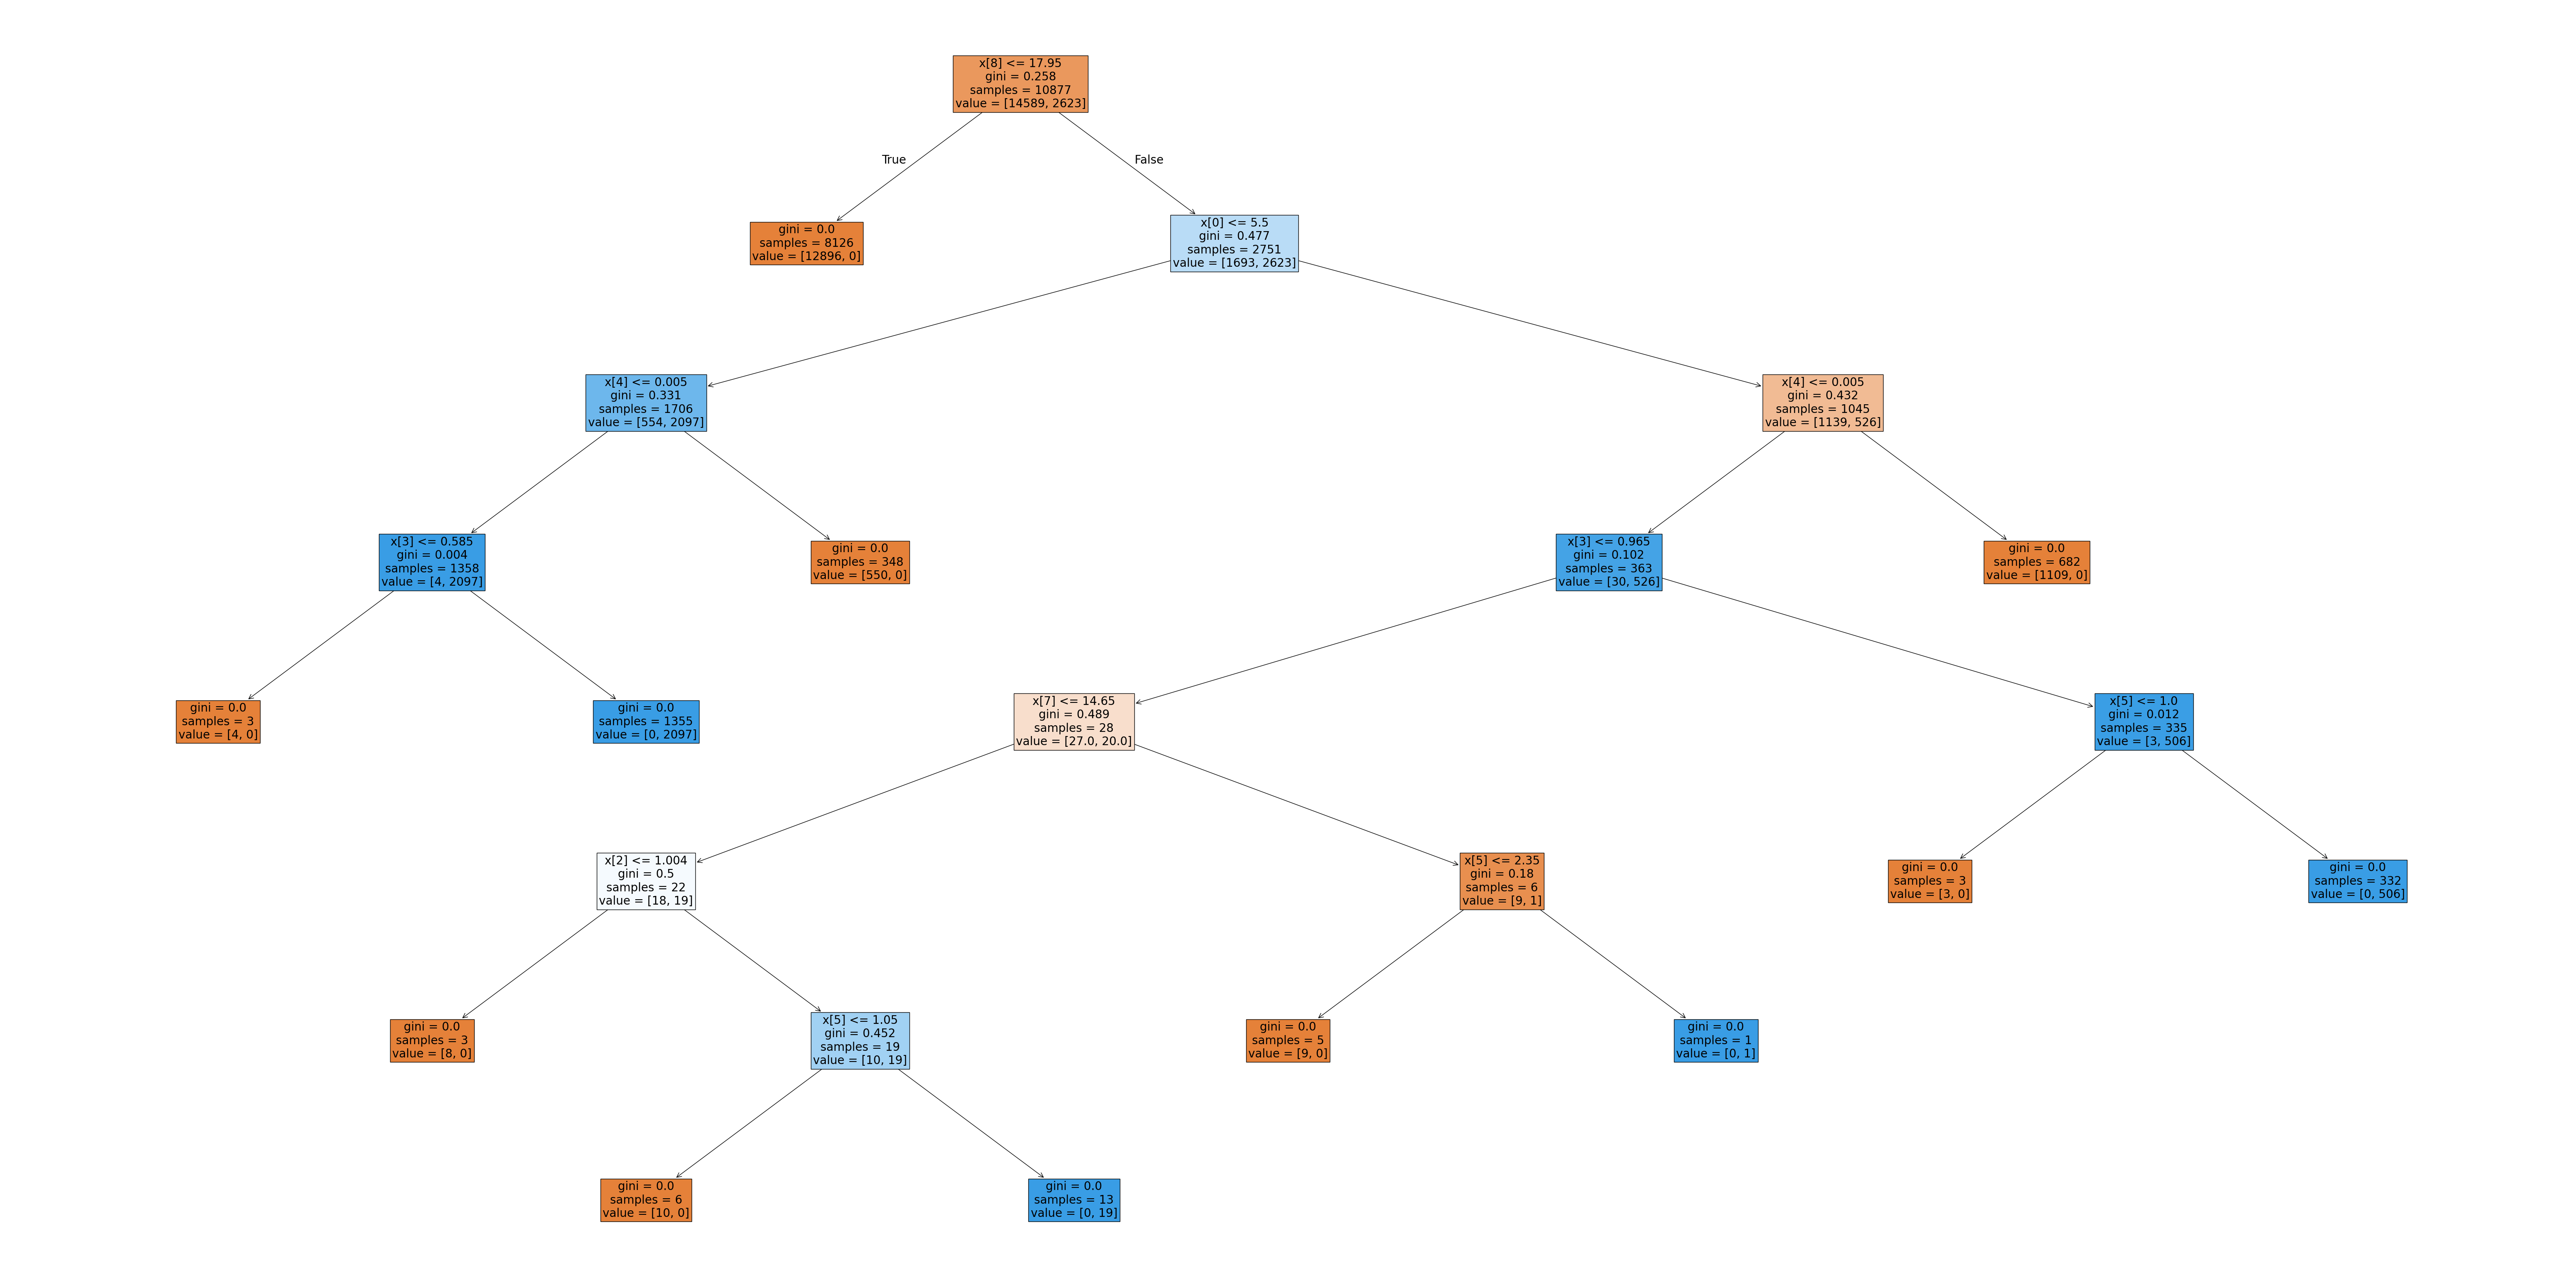

In [29]:
# Class-names = {0:'Unpleasant Weather', 1:'Pleasant Weather'}

fig = plt.figure(figsize=(80,40))
plot_tree(clf.estimators_[6], fontsize = 20, filled=True);

## 6. Feature Importance

In [52]:
# Retrieve feature importance from trained model

newarray = clf.feature_importances_
print(clf.feature_importances_.shape)
newarray

(9,)


array([0.02191756, 0.01531693, 0.01131681, 0.08178739, 0.31290749,
       0.08222071, 0.15607496, 0.03516143, 0.28329672])

In [56]:
# Create a list of weather features

wx_list = [feature.replace('OSLO_', '') for feature in oslo_list]
wx_list

['cloud_cover',
 'humidity',
 'pressure',
 'global_radiation',
 'precipitation',
 'sunshine',
 'temp_mean',
 'temp_min',
 'temp_max']

In [58]:
important = pd.Series(newarray, index = wx_list)
important

cloud_cover         0.021918
humidity            0.015317
pressure            0.011317
global_radiation    0.081787
precipitation       0.312907
sunshine            0.082221
temp_mean           0.156075
temp_min            0.035161
temp_max            0.283297
dtype: float64

['cloud_cover', 'humidity', 'pressure', 'global_radiation', 'precipitation', 'sunshine', 'temp_mean', 'temp_min', 'temp_max']


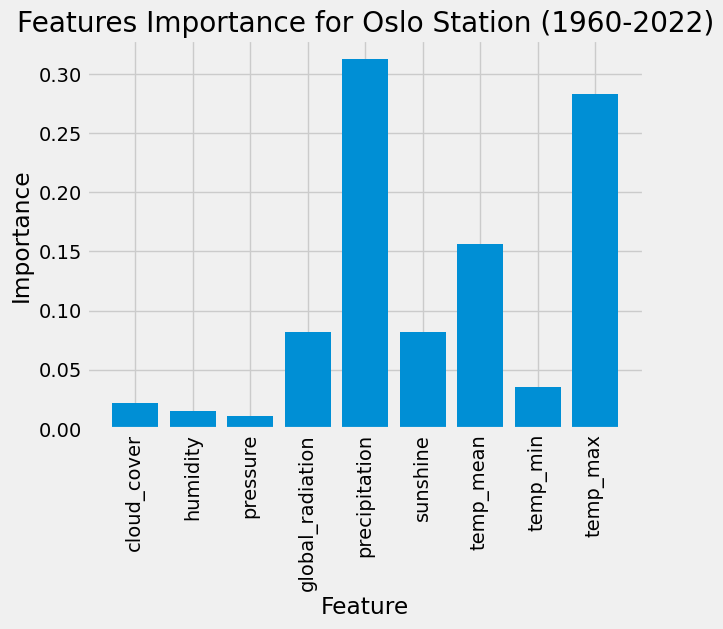

In [60]:
# Plot the results

%matplotlib inline

plt.style.use('fivethirtyeight')
# list of x locations for plotting
x_values = list(range(len(newarray)))
print(wx_list)

plt.bar(x_values, newarray, orientation = 'vertical')
plt.xticks(x_values, wx_list, rotation='vertical')
plt.ylabel('Importance'); plt.xlabel('Feature'); plt.title('Features Importance for Oslo Station (1960-2022)');

plt.show()